In [1]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Loading data files

In [2]:
SOS_token = 0
EOS_token = 1


class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence.split(" "):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [3]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return "".join(
        c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn"
    )


# Lowercase, trim, and remove non-letter characters
def normalizeString(s: str):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

In [4]:
def readLangs(
    lang1: str, lang2: str, reverse: bool = False
) -> tuple[Lang, Lang, list[list[str]]]:
    print("Reading lines...")

    # Read the file and split into lines
    lines = (
        open(f"data/{lang1}-{lang2}.txt", encoding="utf-8").read().strip().split("\n")
    )

    # Split every line into pairs and normalize
    pairs = [[normalizeString(s) for s in l.split("\t")] for l in lines]

    # Reverse pairs, make Lang instances
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang(lang2)
        output_lang = Lang(lang1)
    else:
        input_lang = Lang(lang1)
        output_lang = Lang(lang2)

    return input_lang, output_lang, pairs

In [5]:
MAX_LENGTH = 10

eng_prefixes = (
    "i am ",
    "i m ",
    "he is",
    "he s ",
    "she is",
    "she s ",
    "you are",
    "you re ",
    "we are",
    "we re ",
    "they are",
    "they re ",
)


def filterPair(p):
    return (
        len(p[0].split(" ")) < MAX_LENGTH
        and len(p[1].split(" ")) < MAX_LENGTH
        and p[1].startswith(eng_prefixes)
    )


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [6]:
def prepareData(lang1, lang2, reverse=False):
    input_lang, output_lang, pairs = readLangs(lang1, lang2, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs


input_lang, output_lang, pairs = prepareData("eng", "fra", True)
print(random.choice(pairs))

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
['j ai peur de mourir', 'i m afraid of dying']


## The Seq2Seq Model

### The Encoder

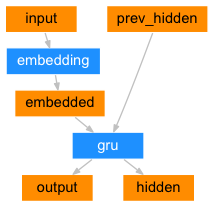

In [7]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super().__init__()

        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(
        self,
        input: torch.Tensor,  # (batch_size, seq_len, hidden_size)
    ) -> tuple[
        torch.Tensor,  # (batch_size, seq_len, hidden_size)
        torch.Tensor,  # (num_layers, batch_size, hidden_size)
    ]:
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

### The Decoder

#### Simple Decoder

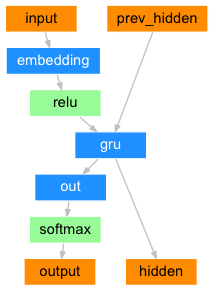

In [8]:
class DecodeRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()

        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(
        self,
        encoder_outputs: torch.Tensor,  # (batch_size, seq_len, embed_dim)
        encoder_hidden: torch.Tensor,  # (num_layers, batch_size, embed_dim)
        target_tensor: None | torch.Tensor = None,  # (batch_size, seq_len)
    ):
        batch_size = encoder_outputs.size(0)
        # (batch_size, 1)
        decoder_input = torch.empty(
            batch_size, 1, dtype=torch.long, device=device
        ).fill_(SOS_token)
        # (num_layers, batch_size, embed_dim)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            # decoder_output: (batch_size, 1, output_size)
            decoder_output, decoder_hidden = self.forward_step(
                decoder_input, decoder_hidden
            )
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1)  # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                # (batch_size, 1, 1)
                _, topi = decoder_output.topk(1)
                # detach from history as inoput
                # (batch_size, 1)
                decoder_input = topi.squeeze(-1).detach()

        # (batch_size, 1, output_size)
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=1)
        return (
            decoder_outputs,
            decoder_hidden,
            None,
        )  # We return `None` for consistency in the training loop

    def forward_step(
        self,
        input: torch.Tensor,  # (batch_size, 1)
        hidden: torch.Tensor,  # (num_layers, batch_size, hidden_size)
    ) -> tuple[
        torch.Tensor,  # (batch_size, 1, output_size)
        torch.Tensor,  # (num_layers, batch_size, hidden_size)
    ]:
        output = self.embedding(input)
        output = F.relu(output)
        output, hidden = self.gru(input, hidden)
        output = self.out(output)
        return output, hidden

### Attention Decoder

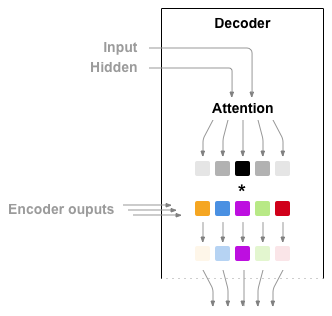
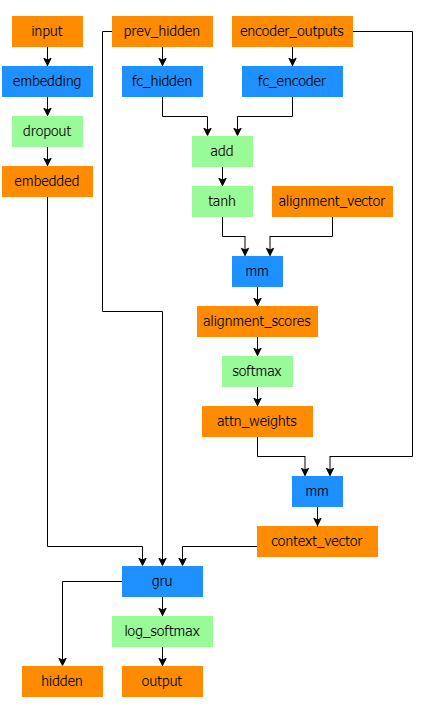

In [ ]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()

        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(
        self,
        query: torch.Tensor,  # (batch_size, 1, embed_dim)
        keys: torch.Tensor,  # (batch_size, seq_len, embed_dim)
    ):
        combined_qk = torch.tanh(
            self.Wa(query) + self.Ua(keys)
        )  # (batch_size, seq_len, embed_dim)
        scores = self.Va(combined_qk)  # (batch_size, seq_len, 1)
        scores = scores.squeeze(2).unsqueeze(1)  # (batch_size, 1, seq_len)

        weights = F.softmax(scores, dim=-1)  # (batch_size, 1, seq_len)
        # (batch_size, 1, seq_len) * (batch_size, seq_len, embed_dim) = (batch_size, 1, embed_dim)
        context = torch.bmm(weights, keys)

        return context, weights


class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size: int, output_size: int, dropout_p: float = 0.1):
        super().__init__()

        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(
        self,
        encoder_outputs: torch.Tensor,  # (batch_size, seq_len, hidden_size)
        encoder_hidden: torch.Tensor,  # (num_layers, batch_size, hidden_size)
        target_tensor: None | torch.Tensor = None,  # (batch_size, seq_len, hidden_size)
    ) -> tuple[
        torch.Tensor,  # (batch_size, seq_len, output_size)
        torch.Tensor,  # (num_layers, batch_size, hidden_size)
        torch.Tensor,  # (batch_size, seq_len, seq_len)
    ]:
        batch_size = encoder_outputs.size(0)
        # (batch_size, 1)
        decoder_input = torch.empty(
            batch_size, 1, dtype=torch.long, device=device
        ).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            # decoder_output: (batch_size, 1, output_size)
            # decoder_hidden: (num_layers, batch_size, hidden_size)
            # attn_weights: (batch_size, 1, seq_len)
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = decoder_output.topk(1)
                # (batch_size, 1)
                deocder_input = topi.squeeze(-1).detach()

        # (batch_size, seq_len, output_size)
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions

    def forward_step(
        self,
        input: torch.Tensor,  # (batch_size, 1)
        hidden: torch.Tensor,  # (batch_size, 1, hidden_size)
        encoder_outputs: torch.Tensor,  # (batch_size, seq_len, hidden_size)
    ) -> tuple[
        torch.Tensor,  # (batch_size, 1, output_size)
        torch.Tensor,  # (num_layers, batch_size, hidden_size)
        torch.Tensor,  # (batch_size, 1, seq_len)
    ]:
        # (batch_size, 1, hidden_size)
        embedded = self.dropout(self.embedding(input))

        # (batch_size, 1, hidden_size)
        query = hidden.permute(1, 0, 2)
        # content: (batch_size, 1, hidden_size)
        # attn_weights: (batch_size, 1, seq_len)
        context, attn_weights = self.attention(query, encoder_outputs)
        # (batch_size, 1, 2 * hidden_size)
        input_gru = torch.cat((embedded, context), dim=2)

        # output: (batch_size, 1, hidden_size)
        # hidden: (num_layers, batch_size, hidden_size)
        output, hidden = self.gru(input_gru, hidden)
        # (batch_size, 1, output_size)
        output = self.out(output)

        return output, hidden, attn_weights

## Training

### Preparing Training Data

In [11]:
def indexesFromSentence(lang: Lang, sentence: str):
    return [lang.word2index[word] for word in sentence.split(" ")]


def tensorFromSentence(lang: Lang, sentence: str):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)


def get_dataloader(batch_size: int):
    input_lang, output_lang, pairs = prepareData("eng", "fra", True)

    n = len(pairs)
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        inp_ids = indexesFromSentence(input_lang, inp)
        tgt_ids = indexesFromSentence(output_lang, tgt)
        inp_ids.append(EOS_token)
        tgt_ids.append(EOS_token)
        input_ids[idx, : len(inp_ids)] = inp_ids
        target_ids[idx, : len(tgt_ids)] = tgt_ids

    train_data = TensorDataset(
        torch.LongTensor(input_ids).to(device),
        torch.LongTensor(target_ids).to(device),
    )
    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(
        train_data, sampler=train_sampler, batch_size=batch_size
    )
    return input_lang, output_lang, train_dataloader

### Training the Model

In [16]:
def train_epoch(
    dataloader: torch.utils.data.DataLoader,
    encoder: torch.nn.Module,
    decoder: torch.nn.Module,
    encoder_optimizer: torch.optim.Optimizer,
    decoder_optimizer: torch.optim.Optimizer,
    criterion: torch.nn.Module,
):
    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss: torch.Tensor = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1),
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [17]:
import time
import math


def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return "%dm %ds" % (m, s)


def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return "%s (- %s)" % (asMinutes(s), asMinutes(rs))

In [18]:
def train(
    train_dataloader,
    encoder,
    decoder,
    n_epochs,
    learning_rate=0.001,
    print_every=100,
    plot_every=100,
):
    start = time.time()
    plot_losses = []
    print_loss_total = 0
    plot_loss_total = 0

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(
            train_dataloader,
            encoder,
            decoder,
            encoder_optimizer,
            decoder_optimizer,
            criterion,
        )
        print_loss_total += loss 
        plot_loss_total += loss 

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s (%d %d%%) %.4f' % (timeSince(start, epoch / n_epochs),
                                        epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)


### Plotting results

In [19]:
import matplotlib.pyplot as plt

plt.switch_backend("agg")
import matplotlib.ticker as ticker
import numpy as np


def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

## Evaluation

In [20]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = tensorFromSentence(input_lang, sentence)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(
            encoder_outputs, encoder_hidden
        )

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append("<EOS>")
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

In [21]:
def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print(">", pair[0])
        print("=", pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = " ".join(output_words)
        print("<", output_sentence)
        print("")

## Training and Evaluating

In [22]:
hidden_size = 128
batch_size = 32

input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

train(train_dataloader, encoder, decoder, 80, print_every=5, plot_every=5)

Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2991
0m 41s (- 10m 20s) (5 6%) 1.5354
1m 15s (- 8m 46s) (10 12%) 0.6765
1m 49s (- 7m 52s) (15 18%) 0.3496
2m 22s (- 7m 8s) (20 25%) 0.1949
2m 55s (- 6m 26s) (25 31%) 0.1211
3m 29s (- 5m 48s) (30 37%) 0.0851
4m 2s (- 5m 11s) (35 43%) 0.0653
4m 34s (- 4m 34s) (40 50%) 0.0539
5m 7s (- 3m 59s) (45 56%) 0.0461
5m 42s (- 3m 25s) (50 62%) 0.0417
6m 15s (- 2m 50s) (55 68%) 0.0377
6m 48s (- 2m 16s) (60 75%) 0.0350
7m 21s (- 1m 41s) (65 81%) 0.0333
7m 53s (- 1m 7s) (70 87%) 0.0322
8m 25s (- 0m 33s) (75 93%) 0.0305
8m 57s (- 0m 0s) (80 100%) 0.0295


In [23]:
encoder.eval()
decoder.eval()
evaluateRandomly(encoder, decoder)

> il fait attention a ses manieres
= he is careful about his manners
< he he he SOS SOS SOS of of of of

> vous etes une sacree menteuse
= you re such a liar
< you you you you you you you you expecting expecting

> je ne suis plus en colere apres toi
= i m no longer angry at you
< i i more SOS SOS SOS SOS SOS SOS SOS

> vous me faites marcher !
= you re kidding !
< you you you you you you you you you you

> tu es inoubliable
= you re unforgettable
< you you you you you you you you you you

> je survis
= i m surviving
< i i i i i i i i i i

> je suis la voisine de tom
= i m tom s neighbor
< i i i i i SOS i i i i

> je ne suis qu un pauvre etudiant
= i m just a poor student
< i i i SOS i i SOS i i i

> ce n est pas un homme ordinaire
= he is no ordinary man
< he he he he he SOS SOS SOS SOS SOS

> je suis heureux que tom fut a mes cotes
= i m glad tom was there with me
< i i tom i i SOS SOS SOS SOS SOS



## Visualizing Attention

input = il n est pas aussi grand que son pere
output = he he he he he he he not not not


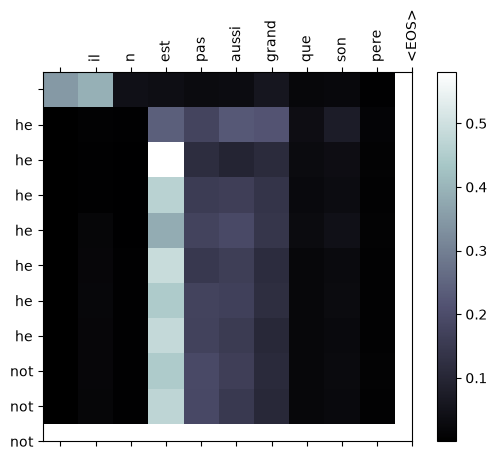

input = je suis trop fatigue pour conduire
output = i i i i SOS SOS SOS SOS SOS SOS


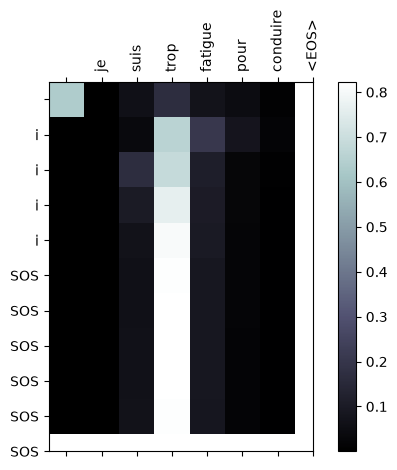

input = je suis desole si c est une question idiote
output = i i i i i i i i i i


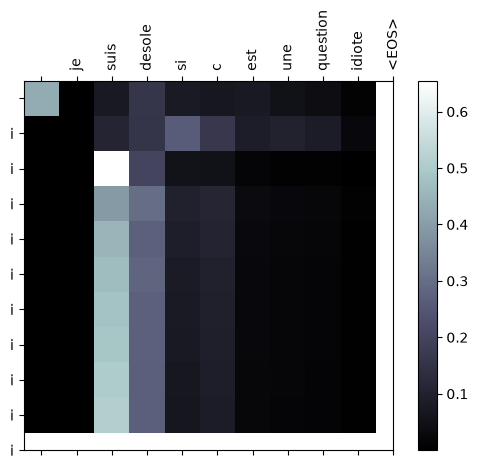

input = je suis reellement fiere de vous
output = i i i i i i i i i i


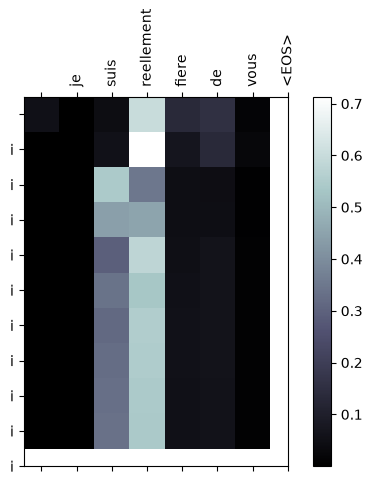

In [32]:
# %matplotlib inline

def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap="bone")
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticks(range(len(input_sentence.split(" ")) + 2))  # 改这里
    ax.set_xticklabels([""] + input_sentence.split(" ") + ["<EOS>"], rotation=90)

    ax.set_yticks(range(len(output_words) + 1))               # 改这里
    ax.set_yticklabels([""] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(
        encoder, decoder, input_sentence, input_lang, output_lang
    )
    print("input =", input_sentence)
    print("output =", " ".join(output_words))
    showAttention(input_sentence, output_words, attentions[0, : len(output_words), :])


evaluateAndShowAttention("il n est pas aussi grand que son pere")

evaluateAndShowAttention("je suis trop fatigue pour conduire")

evaluateAndShowAttention("je suis desole si c est une question idiote")

evaluateAndShowAttention("je suis reellement fiere de vous")